# Modelo - XceptionNet

Juan Muelledes Mateos - Trabajo final de Modelado Computacional, Simulacion y Optimización

## 1. Importamos las librerias necesarias

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import sklearn
import itertools
from sklearn.metrics import classification_report
from tensorflow.keras.applications import *
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import preprocess_input as base_preprocess
from tensorflow.keras.applications.convnext import preprocess_input as base_preprocess
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, RocCurveDisplay, auc
from sklearn.utils.multiclass import unique_labels
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive

## 2. Cargamos datos, dividimos y aumentamos.

In [3]:
drive.mount('/content/drive')

data = np.load('/content/drive/MyDrive/Archivos Modelado/data.npy')
labels = np.load('/content/drive/MyDrive/Archivos Modelado/labels.npy')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
def random_rotation(img, angle_range=20):
    angle = np.random.uniform(-angle_range, angle_range)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h),
                          borderMode=cv2.BORDER_REFLECT_101)
def random_brightness_contrast(img):
    alpha = np.random.uniform(0.8, 1.2)  # contraste
    beta = np.random.uniform(-25, 25)    # brillo
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

def add_gaussian_noise(img):
    noise = np.random.normal(0, 10, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def random_zoom(img, zoom_range=(0.9, 1.1)):
    h, w = img.shape[:2]
    scale = np.random.uniform(*zoom_range)

    new_h, new_w = int(h*scale), int(w*scale)
    resized = cv2.resize(img, (new_w, new_h))

    if scale > 1:
        startx = (new_w - w)//2
        starty = (new_h - h)//2
        return resized[starty:starty+h, startx:startx+w]
    else:
        pad_h = (h - new_h)//2
        pad_w = (w - new_w)//2
        return cv2.copyMakeBorder(
            resized,
            pad_h, h-new_h-pad_h,
            pad_w, w-new_w-pad_w,
            cv2.BORDER_REFLECT_101
        )
def random_blur(img):
    k = np.random.choice([3,5])
    return cv2.GaussianBlur(img, (k,k), 0)

In [5]:
def produce_new_img_strong(img):

    augmented = []

    augmented.append(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))
    augmented.append(cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE))
    augmented.append(cv2.rotate(img, cv2.ROTATE_180))
    augmented.append(cv2.flip(img, 0))
    augmented.append(cv2.flip(img, 1))
    augmented.append(random_rotation(img))
    augmented.append(random_brightness_contrast(img))
    augmented.append(add_gaussian_noise(img))
    augmented.append(random_zoom(img))
    augmented.append(random_blur(img))

    return augmented

In [6]:
import cv2
from cv2 import imread, resize

def apply_augmentation_to_minority_classes(X_train, y_train_one_hot):

    augmented_images = []
    augmented_labels = []
    y_train_indices = np.argmax(y_train_one_hot, axis=1)
    for img, label_idx in zip(X_train, y_train_indices):
        augmented_images.append(img)
        augmented_labels.append(label_idx)
        if label_idx != 5 and label_idx != 2 and label_idx != 4:  # Después de ordenar, 5 es NV, la clase matyoritaria
            new_imgs = produce_new_img_strong(img)
            for new_img in new_imgs:
                augmented_images.append(new_img)
                augmented_labels.append(label_idx)

    augmented_labels_one_hot = to_categorical(augmented_labels, num_classes=7)
    return np.array(augmented_images), augmented_labels_one_hot

In [7]:
train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.1, stratify=labels, random_state=42
)
train_data, val_data, train_labels, val_labels = train_test_split(
    train_data, train_labels, test_size=0.111, stratify=train_labels, random_state=42
)

In [8]:
train_data, train_labels = apply_augmentation_to_minority_classes(train_data, train_labels)

print("Rango de valores en train_data:", train_data.min(), train_data.max())

train_data = (train_data / 127.5) - 1.0
val_data = (val_data / 127.5) - 1.0
test_data = (test_data / 127.5) - 1.0

print("Rango de valores en train_data:", train_data.min(), train_data.max())

Rango de valores en train_data: 0 255
Rango de valores en train_data: -1.0 1.0


## 3. Dividimos los datos a conjuntos de entrenamiento, validación y test

In [9]:
print("train_data shape:", train_data.shape)
print("train_labels shape:", train_labels.shape)
print("val_data shape:", val_data.shape)
print("val_labels shape:", val_labels.shape)
print("test_data shape:", test_data.shape)
print("test_labels shape:", test_labels.shape)

train_data shape: (16792, 224, 224, 3)
train_labels shape: (16792, 7)
val_data shape: (1001, 224, 224, 3)
val_labels shape: (1001, 7)
test_data shape: (1002, 224, 224, 3)
test_labels shape: (1002, 7)


In [10]:
class_names_mapping = {
    0: "AKIEC",
    1: "BCC",
    2: "BKL",
    3: "DF",
    4: "MEL",
    5: "NV",
    6: "VASC"
}

num_classes = train_labels.shape[1]
class_counts_train = np.sum(train_labels, axis=0)
class_counts_val = np.sum(val_labels, axis=0)
class_counts_test = np.sum(test_labels, axis=0)

class_counts_mapping = {}
for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name] = {'Train': class_counts_train[index]}

for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name]['Validation'] = class_counts_val[index]

for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name]['Test'] = class_counts_test[index]

for class_name, counts in class_counts_mapping.items():
    print(class_name)
    for set_name, count in counts.items():
        print(f" - {set_name}: {count}")

y_train_integers = np.argmax(train_labels, axis=1)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)

class_weight_dict = dict(enumerate(class_weights))

class_weight_dict = {i: np.sqrt(w) for i, w in class_weight_dict.items()}

print("\n Pesos para cada clase para paliar desbalance:")
for cls, weight in class_weight_dict.items():
    print(f"Class {class_names_mapping[cls]}: {weight:.4f}")

AKIEC
 - Train: 2871.0
 - Validation: 33.0
 - Test: 33.0
BCC
 - Train: 4532.0
 - Validation: 51.0
 - Test: 51.0
BKL
 - Train: 879.0
 - Validation: 110.0
 - Test: 110.0
DF
 - Train: 1001.0
 - Validation: 12.0
 - Test: 12.0
MEL
 - Train: 891.0
 - Validation: 111.0
 - Test: 111.0
NV
 - Train: 5364.0
 - Validation: 670.0
 - Test: 671.0
VASC
 - Train: 1254.0
 - Validation: 14.0
 - Test: 14.0

 Pesos para cada clase para paliar desbalance:
Class AKIEC: 0.9141
Class BCC: 0.7275
Class BKL: 1.6520
Class DF: 1.5481
Class MEL: 1.6408
Class NV: 0.6687
Class VASC: 1.3831


## 4. Definimos los elementos necesarios para el entrenamiento

### 4.1 Generador de datos aumentados

In [11]:
batch_size = 16

alpha_list = [class_weight_dict[i] for i in range(num_classes)]  # ya es lista de floats

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [12]:
class MixupSequence(tf.keras.utils.Sequence):
    def __init__(self, x, y, batch_size, datagen, alpha=0.2, shuffle=True):
        self.x = x
        self.y = y
        self.batch_size = batch_size
        self.datagen = datagen
        self.alpha = alpha
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.x) / self.batch_size))

    def on_epoch_end(self):
        self.indices = np.arange(len(self.x))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_x = self.x[batch_indices].copy()
        batch_y = self.y[batch_indices].copy()

        # Aplicar transformaciones aleatorias a cada imagen
        for i in range(len(batch_x)):
            batch_x[i] = self.datagen.random_transform(batch_x[i])

        # Mezclar con MixUp
        lam = np.random.beta(self.alpha, self.alpha)
        idx_perm = np.random.permutation(len(batch_x))
        mixed_x = lam * batch_x + (1 - lam) * batch_x[idx_perm]
        mixed_y = lam * batch_y + (1 - lam) * batch_y[idx_perm]
        return mixed_x, mixed_y

train_gen = MixupSequence(train_data, train_labels,
                          batch_size=batch_size,
                          datagen=datagen,
                          alpha=0.2)

### 4.2 Funciones de Callback

In [13]:
lr_reduce = ReduceLROnPlateau(monitor = 'val_accuracy', factor = 0.5, patience = 5,mode='max', min_lr = 1e-5,verbose = 1)
early_stop = EarlyStopping(monitor = 'val_accuracy', patience = 10, mode='max', verbose = 1)
saved_model = '/content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5'
model_chkpt = ModelCheckpoint(saved_model ,save_best_only = True, monitor = 'val_accuracy',verbose = 1)

callback_list = [model_chkpt, lr_reduce, early_stop]

### 4.3 Modelo XceptionNet

In [14]:
base_model = Xception(weights='imagenet',
                      include_top=False,
                      input_shape=(224, 224, 3))

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


### 4.4 Modificación de la red XceptionNet y compilación

In [15]:
from keras.losses import CategoricalFocalCrossentropy

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

loss_fn = CategoricalFocalCrossentropy(alpha=alpha_list, gamma=2.0)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=loss_fn,
              metrics=['accuracy'])

## 5. Entrenamos el modelo

In [ ]:
epochs = 55
batch_size = 16

In [ ]:
history = model.fit(train_gen,
                    validation_data=(val_data, val_labels),
                    epochs=epochs,
                    callbacks=callback_list)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.5997 - loss: 0.8370
Epoch 1: val_accuracy improved from None to 0.80719, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5



Epoch 1: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 364s 276ms/step - accuracy: 0.7004 - loss: 0.6501 - val_accuracy: 0.8072 - val_loss: 0.3808 - learning_rate: 1.0000e-04
Epoch 2/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.8044 - loss: 0.4530
Epoch 2: val_accuracy improved from 0.80719 to 0.81219, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5



Epoch 2: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 215s 204ms/step - accuracy: 0.8125 - loss: 0.4340 - val_accuracy: 0.8122 - val_loss: 0.2801 - learning_rate: 1.0000e-04
Epoch 3/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8478 - loss: 0.3810
Epoch 3: val_accuracy improved from 0.81219 to 0.84515, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5



Epoch 3: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 219s 208ms/step - accuracy: 0.8483 - loss: 0.3778 - val_accuracy: 0.8452 - val_loss: 0.2598 - learning_rate: 1.0000e-04
Epoch 4/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.8687 - loss: 0.3373
Epoch 4: val_accuracy did not improve from 0.84515
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 219s 209ms/step - accuracy: 0.8664 - loss: 0.3355 - val_accuracy: 0.8222 - val_loss: 0.2567 - learning_rate: 1.0000e-04
Epoch 5/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8829 - loss: 0.3290
Epoch 5: val_accuracy improved from 0.84515 to 0.86314, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5


...


Epoch 15: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 226s 215ms/step - accuracy: 0.9447 - loss: 0.2143 - val_accuracy: 0.8911 - val_loss: 0.2489 - learning_rate: 5.0000e-05
Epoch 16/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9509 - loss: 0.1957
Epoch 16: val_accuracy improved from 0.89111 to 0.89610, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5



Epoch 16: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 221s 210ms/step - accuracy: 0.9458 - loss: 0.2086 - val_accuracy: 0.8961 - val_loss: 0.2119 - learning_rate: 5.0000e-05
Epoch 17/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9435 - loss: 0.2224
Epoch 17: val_accuracy did not improve from 0.89610
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 216s 205ms/step - accuracy: 0.9441 - loss: 0.2199 - val_accuracy: 0.8142 - val_loss: 0.2290 - learning_rate: 5.0000e-05
Epoch 18/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9421 - loss: 0.2226
Epoch 18: val_accuracy did not improve from 0.89610
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 216s 206ms/step - accuracy: 0.9502 - loss: 0.2090 - val_accuracy: 0.8871 - val_loss: 0.2311 - learning_rate: 5.0000e-05
Epoch 19/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9501 - loss: 0.2101
Epoch 19: val_accuracy did not improve from 0.89610
1050/1050 ━━━


Epoch 23: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 220s 210ms/step - accuracy: 0.9611 - loss: 0.1877 - val_accuracy: 0.8981 - val_loss: 0.1911 - learning_rate: 2.5000e-05
Epoch 24/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9571 - loss: 0.2014
Epoch 24: val_accuracy did not improve from 0.89810
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 219s 208ms/step - accuracy: 0.9603 - loss: 0.1956 - val_accuracy: 0.8981 - val_loss: 0.2139 - learning_rate: 2.5000e-05
Epoch 25/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9580 - loss: 0.2073
Epoch 25: val_accuracy did not improve from 0.89810
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 214s 203ms/step - accuracy: 0.9589 - loss: 0.1913 - val_accuracy: 0.8911 - val_loss: 0.2236 - learning_rate: 2.5000e-05
Epoch 26/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9564 - loss: 0.1929
Epoch 26: val_accuracy did not improve from 0.89810
1050/1050 ━━━


Epoch 27: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 223s 213ms/step - accuracy: 0.9637 - loss: 0.1804 - val_accuracy: 0.9021 - val_loss: 0.2217 - learning_rate: 2.5000e-05
Epoch 28/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9625 - loss: 0.1832
Epoch 28: val_accuracy improved from 0.90210 to 0.91109, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5



Epoch 28: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 219s 209ms/step - accuracy: 0.9631 - loss: 0.1763 - val_accuracy: 0.9111 - val_loss: 0.2211 - learning_rate: 2.5000e-05
Epoch 29/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9583 - loss: 0.1843
Epoch 29: val_accuracy did not improve from 0.91109
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 215s 205ms/step - accuracy: 0.9583 - loss: 0.1833 - val_accuracy: 0.9101 - val_loss: 0.2145 - learning_rate: 2.5000e-05
Epoch 30/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9578 - loss: 0.1881
Epoch 30: val_accuracy did not improve from 0.91109
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 213s 203ms/step - accuracy: 0.9563 - loss: 0.1870 - val_accuracy: 0.9021 - val_loss: 0.2068 - learning_rate: 2.5000e-05
Epoch 31/55
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9554 - loss: 0.1933
Epoch 31: val_accuracy did not improve from 0.91109
1050/1050 ━━━

In [ ]:
model.load_weights(saved_model)
base_model.trainable = True

for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-6),
              loss="categorical_crossentropy",
              metrics=['accuracy'])

fine_lr_reduce = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, mode='max', min_lr=1e-8, verbose=1)
fine_early_stop = EarlyStopping(monitor='val_accuracy', min_delta=0.001, patience=8, verbose=1)
fine_checkpoint = ModelCheckpoint(saved_model.replace('.h5', '_finetuned.h5'), save_best_only=True, monitor='val_accuracy', verbose=1)

fine_callbacks = [fine_checkpoint, fine_lr_reduce, fine_early_stop]

fine_tune_epochs = 15
history_fine = model.fit(datagen.flow(train_data, train_labels, batch_size=batch_size),
                         validation_data=(val_data, val_labels),
                         epochs=fine_tune_epochs,
                         callbacks=fine_callbacks)

Epoch 1/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9971 - loss: 0.0474
Epoch 1: val_accuracy improved from None to 0.90909, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception_finetuned.h5



Epoch 1: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception_finetuned.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 238s 182ms/step - accuracy: 0.9964 - loss: 0.0333 - val_accuracy: 0.9091 - val_loss: 0.3856 - learning_rate: 1.0000e-06
Epoch 2/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9973 - loss: 0.0159
Epoch 2: val_accuracy improved from 0.90909 to 0.91309, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception_finetuned.h5



Epoch 2: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception_finetuned.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 182s 173ms/step - accuracy: 0.9968 - loss: 0.0155 - val_accuracy: 0.9131 - val_loss: 0.4182 - learning_rate: 1.0000e-06
Epoch 3/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9974 - loss: 0.0130
Epoch 3: val_accuracy did not improve from 0.91309
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 171s 162ms/step - accuracy: 0.9974 - loss: 0.0121 - val_accuracy: 0.9131 - val_loss: 0.4443 - learning_rate: 1.0000e-06
Epoch 4/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9975 - loss: 0.0107
Epoch 4: val_accuracy did not improve from 0.91309
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 171s 163ms/step - accuracy: 0.9972 - loss: 0.0111 - val_accuracy: 0.9111 - val_loss: 0.4558 - learning_rate: 1.0000e-06
Epoch 5/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9977 - loss: 0.0104
Epoch 5: val_accuracy did not improve from 0.91309

Epoch 5: 

## 6. Evaluamos el modelo

In [16]:
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


model.load_weights('/content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception.h5')


model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### 6.1 Precisión del conjunto de test

In [17]:
test_loss, test_accuracy = model.evaluate(test_data, test_labels)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 491ms/step - accuracy: 0.9092 - loss: 0.3956
Test Accuracy: 0.9091816544532776


### 6.2 Informe de clasificación del modelo

In [ ]:
predictions = model.predict(test_data)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)
report = classification_report(true_labels, predicted_labels)

print("Classification Report:")
print(report)

84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       196
           1       1.00      0.99      1.00       308
           2       0.98      1.00      0.99       660
           3       1.00      1.00      1.00        69
           4       0.95      1.00      0.98       668
           5       1.00      0.94      0.97       671
           6       0.98      1.00      0.99        85

    accuracy                           0.98      2657
   macro avg       0.99      0.99      0.99      2657
weighted avg       0.98      0.98      0.98      2657



### 6.3 Matriz de confusion

In [ ]:
cm = confusion_matrix(true_labels, np.round(predicted_labels))
cm

array([[191,   0,   2,   0,   3,   0,   0],
       [  1, 306,   1,   0,   0,   0,   0],
       [  0,   0, 657,   0,   3,   0,   0],
       [  0,   0,   0,  69,   0,   0,   0],
       [  0,   0,   0,   0, 668,   0,   0],
       [  0,   1,  12,   0,  26, 630,   2],
       [  0,   0,   0,   0,   0,   0,  85]])

Normalized confusion matrix


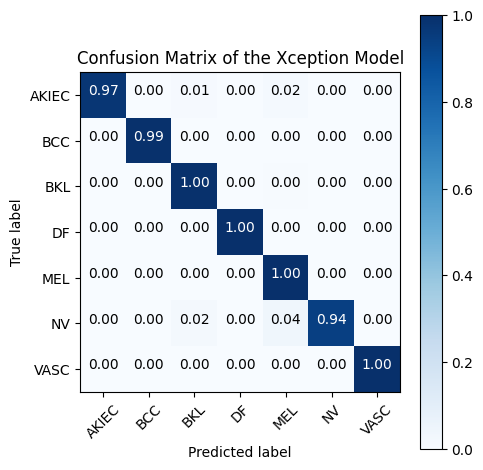

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix for the model Xception',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm_plot_labels = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix of the Xception Model', normalize=True)

Text(0.5, 1.0, 'Accuracy Curves')

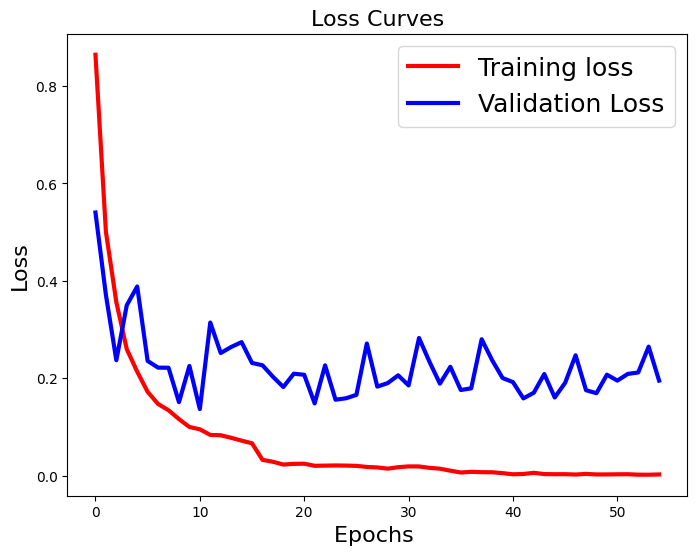

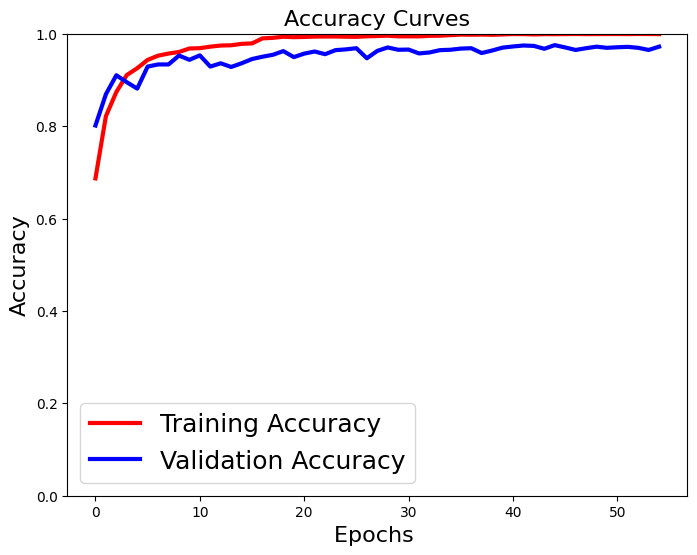

In [ ]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

# Accuracy Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.ylim(0, 1)
plt.title('Accuracy Curves',fontsize=16)